In [1]:
# import bioframe as bf
import torch
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter, whitened_KL
from gpzoo.gp import WSVGP, MGGP_WSVGP
import cooler
from matplotlib.colors import LogNorm
import numpy as np
import cooltools
import pandas as pd
import os, subprocess
from PIL import Image


/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def load_image(infilename, zoom=100):
    image = Image.open(infilename).convert("L")
    image.load()
    width, height = image.size
    print(width, height)

    # Identify the max and min sides
    max_side = max(width, height)
    min_side = min(width, height)

    # Largest side spans from -2 to 2
    max_range = (-10, 10)

    # Scale the smaller side proportionally
    min_range = (-10 * (min_side / max_side), 10 * (min_side / max_side))

    # Assign correct ranges based on whether width or height is larger
    if width >= height:
        x1 = torch.linspace(*max_range, width)   # X-coordinates always -2 to 2
        x2 = torch.linspace(*min_range, height)  # Scaled Y-coordinates
    else:
        x1 = torch.linspace(*min_range, width)   # Scaled X-coordinates
        x2 = torch.linspace(*max_range, height)  # Y-coordinates always -2 to 2

    # Create a meshgrid with correct indexing
    x2 = -x2
    x1, x2 = torch.meshgrid(x1, x2, indexing="xy")

    # Stack the grid into a coordinate array
    X = torch.stack([x1.flatten(), x2.flatten()], dim=1)

    # Convert image to a numpy array (flattened)
    image_array = np.array(image).reshape(-1)

    return torch.tensor(image_array).type(torch.float), X.type(torch.float)

In [3]:
patrick_array, patrick_X = load_image('images/Patrick.jpg')
sponge_array, sponge_X = load_image('images/spongebob.png')

400 640
1152 1152


In [4]:
sponge_X

tensor([[-10.0000,  10.0000],
        [ -9.9826,  10.0000],
        [ -9.9652,  10.0000],
        ...,
        [  9.9652, -10.0000],
        [  9.9826, -10.0000],
        [ 10.0000, -10.0000]])

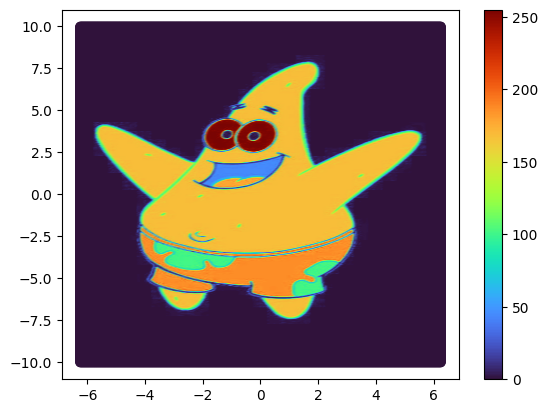

In [5]:
plt.scatter(patrick_X[:, 0], patrick_X[:, 1], c=patrick_array, cmap='turbo', vmin=0, vmax=255)
plt.colorbar()

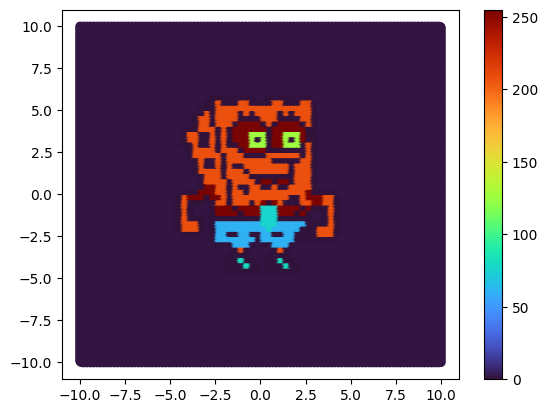

In [6]:
plt.scatter(sponge_X[:, 0][::11], sponge_X[:, 1][::11], c=sponge_array[::11], cmap='turbo')
plt.colorbar()

In [7]:
patrick_mask = patrick_array>0.0
X = patrick_X[patrick_mask][::50]
y = patrick_array[patrick_mask][::50]
groupsX = (X[:,0] < 0).type(torch.long)
print(len(X))

1988


In [8]:
M = 1250
jitter = 1e-2

kernel = batched_MGGP_RBF(sigma=24.0, lengthscale=0.04, group_diff_param=1.0, n_groups=2)
gp = MGGP_WSVGP(kernel, M=M, jitter=jitter, n_groups=2)

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)

gp.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
gp.groupsZ = nn.Parameter(groupsX[idx], requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))

mu = gp.init_mean(X, y, groupsX=groupsX)
gp.mu = nn.Parameter(mu.T)

/tmp/ipykernel_810412/4043401795.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


torch.Size([1988, 1250])
torch.Size([1988])


/tmp/ipykernel_810412/4043401795.py:15: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647380992/work/aten/src/ATen/native/TensorShape.cpp:3683.)
  gp.mu = nn.Parameter(mu.T)


In [9]:
gp.mu.shape

torch.Size([1250])

In [10]:
# Define the grid range and resolution
grid_test = 100  # Number of points per dimension
x1 = torch.linspace(-10, 10, grid_test)
x2 = torch.linspace(-10, 10, grid_test)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X_test = torch.stack([x1.flatten(), x2.flatten()], dim=1)
groups_test=  (X_test[:,0] < 0).type(torch.long)


In [11]:
gp.jitter = 1e-3
qF, qZ, pZ = gp(X_test, diag=False, groupsX=groups_test)

In [12]:
N = 25
F_samples = qF.sample((N,)).detach()
F_mean = qF.mean.detach()

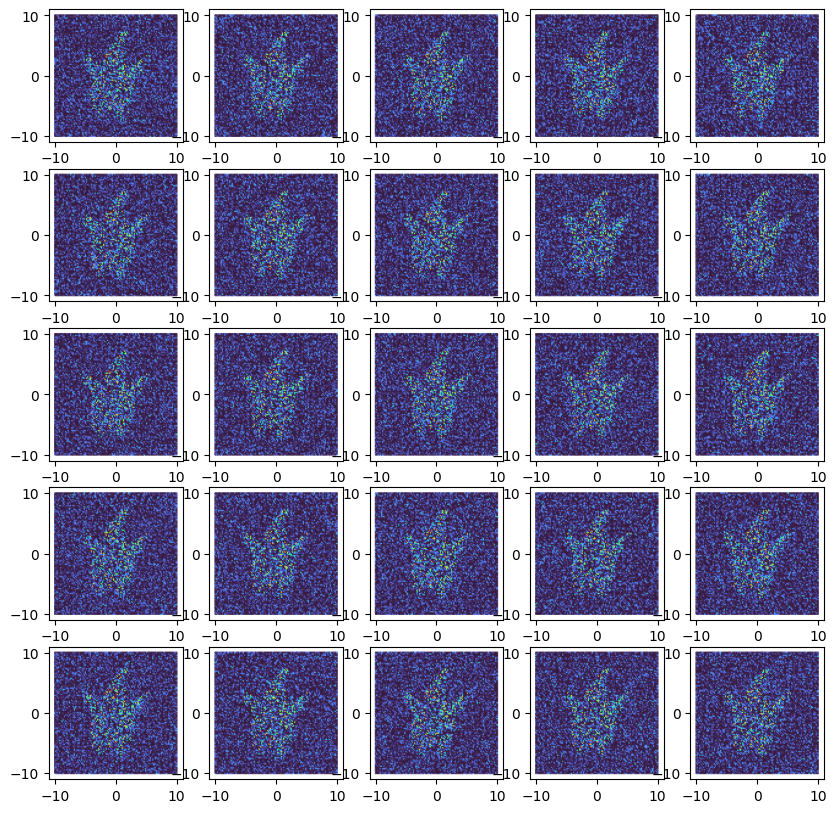

In [13]:
plt.figure(figsize=(10, 10))
for i in range(N):
    plt.subplot(5, 5, i+1)
    plt.scatter(X_test[:, 0], X_test[:, 1], s=0.2, c=F_samples[i], cmap='turbo', vmin=0, vmax=255)

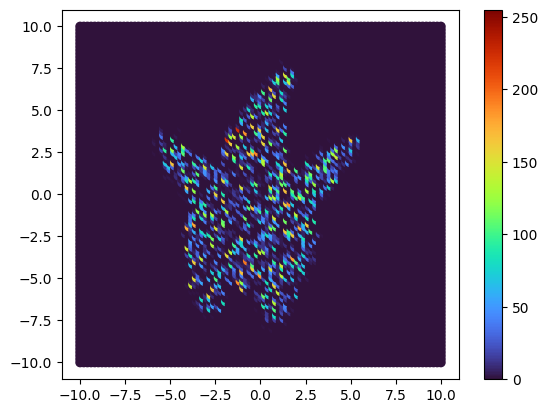

In [14]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=F_mean,  cmap='turbo', vmin=0, vmax=255)
plt.colorbar()

In [15]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor


def kmeans_sampling(X, num_samples=2000):
    """Uses K-Means clustering to select `num_samples` representative points."""
    num_points = X.shape[0]
    if num_points <= num_samples:
        return X  # Return all points if there are fewer than needed

    kmeans = KMeans(n_clusters=num_samples, random_state=42, n_init=10, max_iter=100)
    kmeans.fit(X.numpy())

    return torch.tensor(kmeans.cluster_centers_)  # Return cluster centers

def random_forest_regression(X_train, y_train, X_test):
    """Trains a Random Forest Regressor and predicts y-values for sampled points."""
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train.numpy(), y_train.numpy())  # Train on original data
    return torch.tensor(model.predict(X_test.numpy()))  # Predict for sampled points


def knn_regression(X_train, y_train, X_test, k=5):
    """Uses k-Nearest Neighbors Regression to predict y-values."""
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train.numpy(), y_train.numpy())
    return torch.tensor(model.predict(X_test.numpy()))

In [16]:
sponge_mask = sponge_array>1.0
sponge_X_masked = kmeans_sampling(sponge_X[sponge_mask], num_samples=2000)
sponge_y_masked = random_forest_regression(sponge_X[sponge_mask], sponge_array[sponge_mask], sponge_X_masked)
# sponge_y_masked = knn_regression(sponge_X[sponge_mask], sponge_array[sponge_mask], sponge_X_masked)

sponge_groups = (sponge_y_masked > 0).type(torch.long)

patrick_mask = patrick_array>7.0
patrick_X_masked = kmeans_sampling(patrick_X[patrick_mask], num_samples=2000)
patrick_y_masked = random_forest_regression(patrick_X[patrick_mask], patrick_array[patrick_mask], patrick_X_masked)
patrick_groups = (patrick_y_masked < 0).type(torch.long)

X = torch.concat([sponge_X_masked, patrick_X_masked])
y = torch.concat([sponge_y_masked, patrick_y_masked])
groups = torch.concat([sponge_groups, patrick_groups])

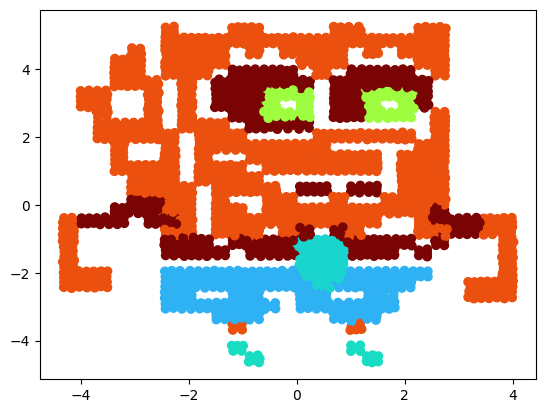

In [17]:
torch.manual_seed(0)
# groups = torch.randint(low=0, high=2, size= (len(X),) ).type(torch.long)
plt.scatter(sponge_X_masked[:, 0], sponge_X_masked[:, 1], c=sponge_y_masked, vmin=0, vmax=255, cmap='turbo')

In [18]:
patrick_y_masked.min()

tensor(9.3500, dtype=torch.float64)

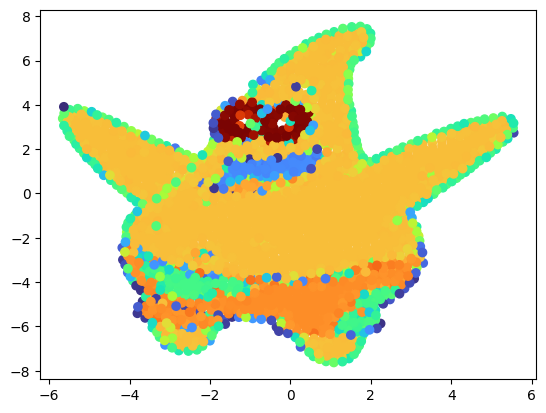

In [19]:
plt.scatter(patrick_X_masked[:, 0], patrick_X_masked[:, 1], c=patrick_y_masked, vmin=0, vmax=255, cmap='turbo')

In [20]:
y = y.type(torch.float)

In [21]:
M = 2000
jitter = 1e-3

kernel = batched_MGGP_RBF(sigma=24.0, lengthscale=0.2, group_diff_param=10000.0, n_groups=2)
gp = MGGP_WSVGP(kernel, M=M, jitter=jitter, n_groups=2)

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)

gp.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
gp.groupsZ = nn.Parameter(groups[idx], requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
mu = gp.init_mean(X, y, groupsX=groups)
gp.mu = nn.Parameter(mu.T)

/tmp/ipykernel_810412/3939091750.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


torch.Size([4000, 2000])
torch.Size([4000])


In [22]:
# Define the grid range and resolution
grid_test = 100  # Number of points per dimension
x1 = torch.linspace(-10, 10, grid_test)
x2 = torch.linspace(-10, 10, grid_test)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X_test = torch.stack([x1.flatten(), x2.flatten()], dim=1)
groups_test_random = torch.randint(low=0, high=2, size= (len(X_test),) ).type(torch.long)
groups_test_sponge=  (torch.ones(len(X_test))*1).type(torch.long)
groups_test_patrick=  (torch.ones(len(X_test))*0).type(torch.long)
groups_test_half=  (X_test[:,0] > 0).type(torch.long)


In [57]:
gp.jitter = 1e-4
gp.kernel.group_diff_param = nn.Parameter(torch.tensor(100.0))
qF, qZ, pZ = gp(X_test, diag=False, groupsX=groups_test_half)

In [58]:
N = 25
F_samples = qF.sample((N,)).detach()
F_mean = qF.mean.detach()

In [59]:
# plt.figure(figsize=(10, 10))
# for i in range(N):
#     plt.subplot(5, 5, i+1)
#     plt.scatter(X_test[:, 0], X_test[:, 1], s=0.2, c=F_samples[i], cmap='turbo', vmin=0, vmax=255)

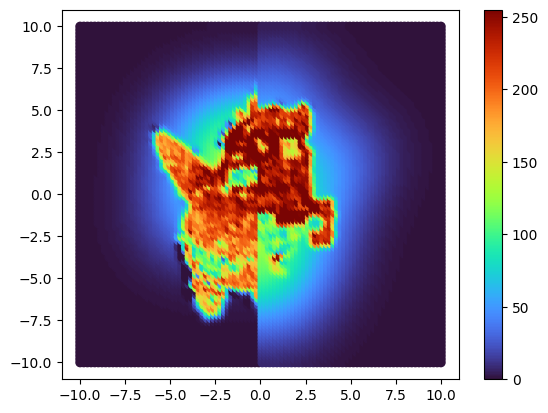

In [60]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=F_mean,  cmap='turbo', vmin=0, vmax=255)
plt.colorbar()